<a href="https://colab.research.google.com/github/jerry124/ProyectoFinal/blob/master/Proyecto_Final_Clasificaci%C3%B3n_Binaria_para_la_Detecci%C3%B3n_de_Ocupaci%C3%B3n_utilizando_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final: Clasificación Binaria para la Detección de Ocupación utilizando Machine Learning**
Autor

# *Gerardo Valdez Martínez*

# **Introducción**

En este proyecto se desarrolla un modelo de Machine Learning capaz de detectar la ocupación de un espacio cerrado utilizando variables ambientales.

El objetivo principal es analizar cómo factores como la temperatura, humedad, iluminación y concentración de CO₂ permiten identificar patrones relacionados con la presencia de personas dentro de una habitación.

Para resolver este problema se emplea un modelo de clasificación supervisada basado en Regresión Logística, el cual permite clasificar si un espacio se encuentra ocupado o desocupado.

# **Objetivo General**

Desarrollar un modelo de clasificación binaria mediante técnicas de Machine Learning capaz de predecir la ocupación de un espacio utilizando variables ambientales.

# **Objetivos Específicos**
Realizar la limpieza y exploración del conjunto de datos.
Analizar la relación entre las variables ambientales y la ocupación.
Aplicar técnicas de preprocesamiento y normalización.
Balancear las clases utilizando SMOTE.
Entrenar un modelo de Regresión Logística.
Evaluar el desempeño del modelo mediante métricas de clasificación.

In [19]:
# ==========================
# LIBRERÍAS PRINCIPALES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Balanceo de clases
from imblearn.over_sampling import SMOTE

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [20]:
# ==============================
# 1. DESCARGA DEL DATASET
# ==============================

# kagglehub permite descargar datasets directamente desde Kaggle.
import kagglehub

# os ayuda a trabajar con rutas y archivos del sistema.
import os

# shutil permite copiar archivos de una carpeta a otra.
import shutil

# Descarga la versión más reciente del dataset de detección de ocupación.
dataset_path = kagglehub.dataset_download("pooriamst/occupancy-detection")

print("Dataset descargado en:")
print(dataset_path)

# Carpeta destino donde se copiarán los archivos para usarlos fácilmente en Colab.
destino = "/content"

# Copia cada archivo del dataset descargado hacia la carpeta /content.
for archivo in os.listdir(dataset_path):
    origen_archivo = os.path.join(dataset_path, archivo)
    destino_archivo = os.path.join(destino, archivo)

    shutil.copy(origen_archivo, destino_archivo)
    print(f"Archivo copiado: {archivo}")

print("\nTodos los archivos fueron copiados a /content")


Using Colab cache for faster access to the 'occupancy-detection' dataset.
Dataset descargado en:
/kaggle/input/occupancy-detection
Archivo copiado: datatest.csv
Archivo copiado: datatrain.csv

Todos los archivos fueron copiados a /content


In [21]:
# ==========================
# CARGA DEL DATASET
# ==========================

ruta = "/content/datatest.csv"

# Cargar datos
DF = pd.read_csv(ruta)

# Mostrar primeras filas
DF.head()

,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,140,02/02/15 14:19,23.7000,26.272,585.200000,749.200000,0.004764,1
1,141,02/02/15 14:19,23.7180,26.290,578.400000,760.400000,0.004773,1
2,142,02/02/15 14:21,23.7300,26.230,572.666667,769.666667,0.004765,1
3,143,02/02/15 14:22,23.7225,26.125,493.750000,774.750000,0.004744,1
4,144,02/02/15 14:23,23.7540,26.200,488.600000,779.000000,0.004767,1


In [22]:
# ==========================
# INFORMACIÓN GENERAL
# ==========================

print(DF.info())

# Dimensiones del dataset
print("\nDimensiones:", DF.shape)

# Valores nulos
print("\nValores nulos:")
print(DF.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2665 entries, 0 to 2664
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2665 non-null   int64  
 1   date           2665 non-null   object 
 2   Temperature    2665 non-null   float64
 3   Humidity       2665 non-null   float64
 4   Light          2665 non-null   float64
 5   CO2            2665 non-null   float64
 6   HumidityRatio  2665 non-null   float64
 7   Occupancy      2665 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 166.7+ KB
None

Dimensiones: (2665, 8)

Valores nulos:
id               0
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64


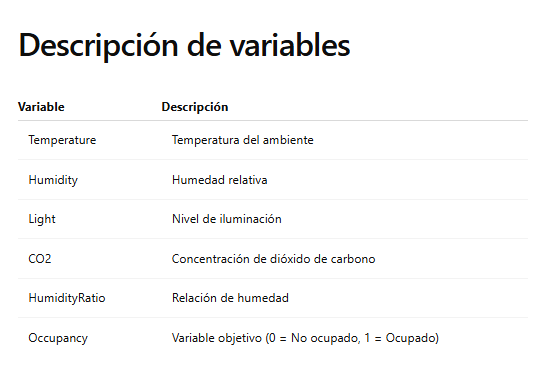

# **Conversión de Fecha y Hora**

In [23]:
# ==========================
# CONVERSIÓN DE FECHA Y HORA
# ==========================

DF['date'] = pd.to_datetime(DF['date'])

# Extraer componentes
DF['Hora'] = DF['date'].dt.hour
DF['Minuto'] = DF['date'].dt.minute

# Mostrar cambios
DF.head()

/tmp/ipykernel_2810/3375866885.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  DF['date'] = pd.to_datetime(DF['date'])


,id,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,Hora,Minuto
0,140,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1,14,19
1,141,2015-02-02 14:19:00,23.7180,26.290,578.400000,760.400000,0.004773,1,14,19
2,142,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1,14,21
3,143,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1,14,22
4,144,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1,14,23


# **Eliminación de columnas innecesarias**

In [24]:
# ==========================
# ELIMINAR COLUMNAS
# ==========================

DF = DF.drop(columns=['date'])

DF.head()

,id,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,Hora,Minuto
0,140,23.7000,26.272,585.200000,749.200000,0.004764,1,14,19
1,141,23.7180,26.290,578.400000,760.400000,0.004773,1,14,19
2,142,23.7300,26.230,572.666667,769.666667,0.004765,1,14,21
3,143,23.7225,26.125,493.750000,774.750000,0.004744,1,14,22
4,144,23.7540,26.200,488.600000,779.000000,0.004767,1,14,23


# Análisis de **correlación**

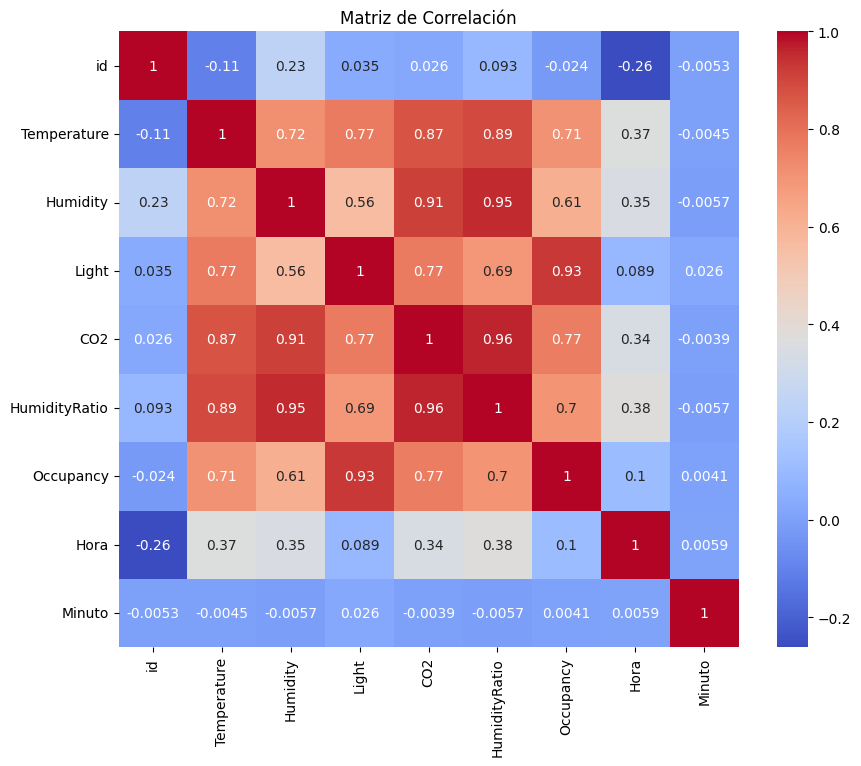

In [25]:
# ==========================
# MATRIZ DE CORRELACIÓN
# ==========================

plt.figure(figsize=(10,8))

sns.heatmap(
    DF.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlación')
plt.show()

# **Balance de clases**

Occupancy
0    1693
1     972
Name: count, dtype: int64


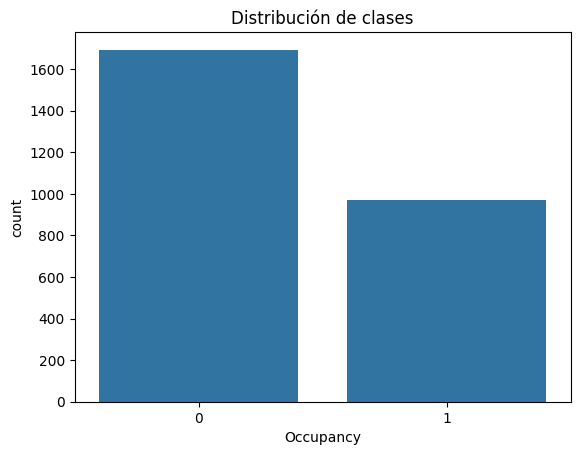

In [26]:
# ==========================
# BALANCE DE CLASES
# ==========================

print(DF['Occupancy'].value_counts())

sns.countplot(x='Occupancy', data=DF)
plt.title('Distribución de clases')
plt.show()

# Separación de **variables**

In [27]:
# ==========================
# VARIABLES X Y Y
# ==========================

X = DF.drop('Occupancy', axis=1)
y = DF['Occupancy']

División de datos

In [28]:
# ==========================
# DIVISIÓN DE DATOS
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **Normalización de variables**

In [29]:
# ==========================
# NORMALIZACIÓN
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Balanceo de clases con SMOTE**

In [30]:
# ==========================
# SMOTE
# ==========================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Distribución después de SMOTE:")
print(pd.Series(y_train_smote).value_counts())



Distribución después de SMOTE:
Occupancy
0    1354
1    1354
Name: count, dtype: int64


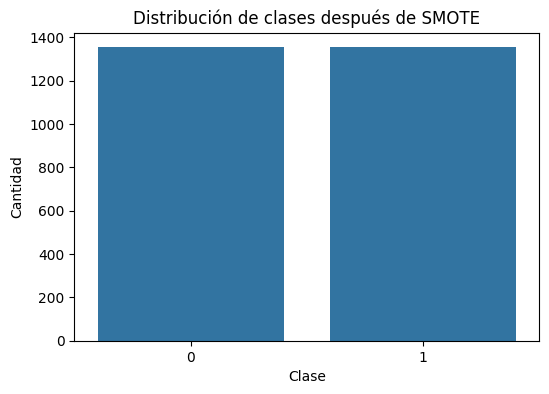

In [41]:
# ==========================
# GRÁFICA DESPUÉS DE SMOTE
# ==========================

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title('Distribución de clases después de SMOTE')
plt.xlabel('Clase')
plt.ylabel('Cantidad')

plt.show()

# **Entrenamiento del modelo**

In [31]:
# ==========================
# MODELO DE CLASIFICACIÓN
# ==========================

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

# **Predicciones**

In [32]:
# ==========================
# PREDICCIONES
# ==========================

predicciones = modelo.predict(X_test_scaled)

# **Evaluación del modelo**

In [33]:
# ==========================
# MÉTRICAS
# ==========================

accuracy = accuracy_score(y_test, predicciones)

print("Accuracy:", accuracy)

print("\nReporte de clasificación:\n")
print(classification_report(y_test, predicciones))

Accuracy: 0.9774859287054409

Reporte de clasificación:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       339
           1       0.94      1.00      0.97       194

    accuracy                           0.98       533
   macro avg       0.97      0.98      0.98       533
weighted avg       0.98      0.98      0.98       533



# **Matriz de confusión**

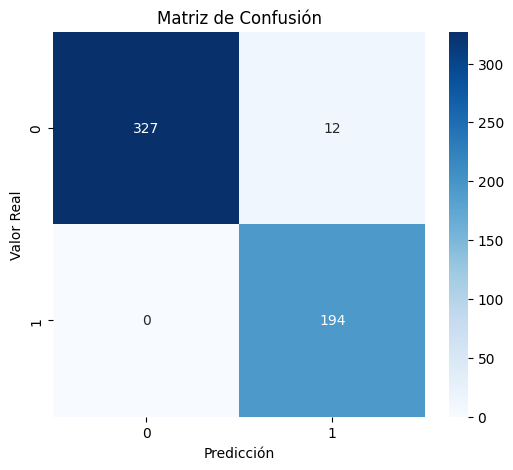

In [34]:
# ==========================
# MATRIZ DE CONFUSIÓN
# ==========================

cm = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')

plt.show()

# **Interpretación de resultados**

El modelo obtuvo una precisión aproximada del 97.75%, lo que demuestra una alta capacidad para identificar correctamente si un espacio se encuentra ocupado o no ocupado.

Las métricas de precisión, recall y F1-score muestran un desempeño balanceado entre ambas clases, indicando que el modelo generaliza adecuadamente los datos.

Además, la matriz de confusión muestra una baja cantidad de errores de clasificación.

# **Conclusión**

El uso de técnicas de Machine Learning permitió desarrollar un sistema de clasificación eficiente para la detección de ocupación en espacios cerrados.

El modelo de Regresión Logística presentó un desempeño sobresaliente, alcanzando una precisión cercana al 98%, demostrando que las variables ambientales contienen información suficiente para identificar patrones de ocupación.

Este tipo de sistemas puede ser aplicado en automatización inteligente, ahorro energético y monitoreo de espacios.

# **2 SVM**

# **1. Importar**

In [35]:
from sklearn.svm import SVC

# **2. Crear modelo**

In [36]:
# ==========================
# MODELO SVM
# ==========================

modelo_svm = SVC(kernel='rbf')

modelo_svm.fit(X_train_smote, y_train_smote)

SVC()

# **3. Predicciones**

In [37]:
pred_svm = modelo_svm.predict(X_test_scaled)

# **4. Evaluación**

In [38]:
accuracy_svm = accuracy_score(y_test, pred_svm)

print("Accuracy SVM:", accuracy_svm)

print("\nReporte de clasificación SVM:\n")

print(classification_report(y_test, pred_svm))

Accuracy SVM: 0.9774859287054409

Reporte de clasificación SVM:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       339
           1       0.94      1.00      0.97       194

    accuracy                           0.98       533
   macro avg       0.97      0.98      0.98       533
weighted avg       0.98      0.98      0.98       533



In [39]:
print("Logistic Regression:", accuracy)
print("SVM:", accuracy_svm)

Logistic Regression: 0.9774859287054409
SVM: 0.9774859287054409
